<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/ols3_from_preprocess(newest).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OLS-3 (+Huber) — Load from Preprocess Parquet

**Based on:** Gu, Kelly & Xiu (2020) "Empirical Asset Pricing via Machine Learning"

This notebook:
1. Loads pre-processed data from `preprocess_data.parquet` (generated by `data_preprocess_corrected_v2.ipynb`)
2. Runs OLS-3 + Huber expanding-window estimation (1987–2016)
3. Reports $R^2_{oos}$ for **All stocks / Top 1000 / Bottom 1000** (Table 1 of paper)

**Important:** The parquet already contains:
- All 94 rank-normalized characteristics (mapped to [-1, 1])
- `exret_lead1` — the prediction target ($r_{i,t+1}$)
- 8 macro variables (lagged 1 month)

→ **No preprocessing or re-normalization needed in this notebook.**

---
| Sample period | Description |
|---|---|
| 1957-03 ~ 1974-12 | Training (expanding) |
| 1975-01 ~ 1986-12 | Validation (rolling 12y) |
| 1987-01 ~ 2016-12 | Test (out-of-sample) |

## 0. Setup & Load Data

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, HuberRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print('Setup complete.')

Mounted at /content/drive
Setup complete.


In [ ]:
# ── Load only the columns needed for OLS-3 ──────────────────────────────────
# The preprocess parquet is ~1.9 GB; loading only needed columns is much faster.
PARQUET_PATH = '/content/drive/MyDrive/industry_project/preprocess_data.parquet'
NEEDED_COLS  = ['permno', 'DATE', 'mvel1', 'bm', 'mom12m', 'exret_lead1']

df_raw = pd.read_parquet(PARQUET_PATH, columns=NEEDED_COLS)
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])

print(f"Loaded shape:  {df_raw.shape}")
print(f"Date range:    {df_raw['DATE'].min().date()} to {df_raw['DATE'].max().date()}")
print(f"exret_lead1 NaN: {df_raw['exret_lead1'].isna().sum():,}")
df_raw.head(3)

Loaded shape:  (3712808, 6)
Date range:    1957-04-30 to 2016-12-30
exret_lead1 NaN: 0


,permno,DATE,mvel1,bm,mom12m,exret_lead1
0,10000,1986-02-28,-0.381006,0.0,0.0,0.359385
1,10000,1986-03-31,-0.505829,0.0,0.0,-0.103792
2,10000,1986-04-30,-0.410132,0.0,0.0,-0.227556


## 1. Model Configuration

| Parameter | Value | Reference |
|---|---|---|
| Features | `mvel1`, `bm`, `mom12m` | OLS-3 (size, value, momentum) |
| Target | `exret_lead1` | $r_{i,t+1}$ — next month excess return |
| Train | 1957 → (year-13), expanding | Paper Section 3.1 |
| Validation | rolling 12 years | Paper Section 2.1 |
| Test | 1987–2016 | Paper Section 3.1 |
| Huber $\xi$ | 99.9th percentile of validation \|residuals\| | Paper Section 2.2.1 |

In [ ]:
# ── Constants ────────────────────────────────────────────────────────────────
CHAR_COLS        = ['mvel1', 'bm', 'mom12m']
TARGET           = 'exret_lead1'
VALIDATION_END   = pd.Timestamp('1986-12-31')
TEST_END         = pd.Timestamp('2016-12-31')
VALIDATION_YEARS = 12

# ── Clean: drop rows missing any required column ─────────────────────────────
REQUIRED = CHAR_COLS + [TARGET]

df = df_raw.sort_values(['DATE', 'permno']).reset_index(drop=True)
df_clean = df.dropna(subset=REQUIRED).copy()

print(f"Clean rows: {len(df_clean):,} / {len(df):,}")

# ── Test years ───────────────────────────────────────────────────────────────
test_years = sorted(
    df_clean.loc[
        (df_clean['DATE'] > VALIDATION_END) &
        (df_clean['DATE'] <= TEST_END),
        'DATE'
    ].dt.year.unique()
)
print(f"Test period: {test_years[0]}–{test_years[-1]}  ({len(test_years)} years)")

Clean rows: 3,712,808 / 3,712,808
Test period: 1987–2016  (30 years)


## 2. Helper Functions

In [ ]:
def build_X(data):
    """Feature matrix for OLS-3 (shape: n × 3)."""
    return data[CHAR_COLS].to_numpy(dtype=np.float64)


def oos_r2(y_true, y_pred):
    """
    Out-of-sample R² with zero benchmark — Equation (19):
        R²_oos = 1 - Σ(r - r̂)² / Σr²
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)


def robust_scale_mad(x):
    """
    Robust scale estimate via MAD:
        scale = median(|x - median(x)|) / 0.6745
    Used to convert absolute xi to sklearn epsilon.
    """
    x   = np.asarray(x, dtype=np.float64)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    s   = mad / 0.6745
    if not np.isfinite(s) or s < 1e-12:
        s = max(np.std(x, ddof=0), 1e-12)
    return float(s)


print('Helper functions defined.')

Helper functions defined.


## 3. Expanding-Window OLS-3 + Huber Estimation (1987–2016)

Per **Appendix D**: *"Parameters are estimated from the training data alone. Each time we refit, we increase the training sample by a year, while maintaining a fixed size rolling sample for validation."*

For each test year $y$:
1. **Train** (expanding): all data up to year $y - 1 - 12$ — model is **fit on this window only**
2. **Val** (rolling 12y): data from $(y - 13)$ to $(y - 1)$ — used **only** to tune $\xi$, never for fitting
3. Temporary OLS on train → compute val residuals → $\xi$ = 99.9th percentile of $|\text{residuals}|$
4. **Fit Huber on train only** with tuned $\xi$ (converted to sklearn `epsilon`)
5. **Predict** test year → store predictions with `mvel1` for Top/Bottom 1000 sorting

In [ ]:
all_preds = []

for year in test_years:

    train_cutoff = pd.Timestamp(f'{year - 1}-12-31')
    val_start    = pd.Timestamp(f'{year - 1 - VALIDATION_YEARS}-12-31')

    df_train = df_clean[df_clean['DATE'] <= val_start]
    df_val   = df_clean[(df_clean['DATE'] > val_start) & (df_clean['DATE'] <= train_cutoff)]
    df_test  = df_clean[df_clean['DATE'].dt.year == year]

    if min(len(df_train), len(df_val), len(df_test)) == 0:
        continue

    # Build matrices — multiply by 100 to keep returns in % units
    X_train = build_X(df_train);  y_train = df_train[TARGET].to_numpy() * 100
    X_val   = build_X(df_val);    y_val   = df_val[TARGET].to_numpy()   * 100
    X_test  = build_X(df_test);   y_test  = df_test[TARGET].to_numpy()  * 100

    # Step 1: OLS on train → validation residuals
    ols_tmp   = LinearRegression(fit_intercept=True).fit(X_train, y_train)
    abs_resid = np.abs(y_val - ols_tmp.predict(X_val))

    # Step 2: xi = 99.9th percentile of |validation residuals|  (paper Section 2.2.1)
    xi_abs  = float(np.quantile(abs_resid, 0.999))
    scale   = robust_scale_mad(y_val - ols_tmp.predict(X_val))
    epsilon = max(xi_abs / scale, 1.0001)   # sklearn requires epsilon > 1

    # Step 3: Huber on TRAIN ONLY
    # Paper Appendix D: "parameters are estimated from the training data alone"
    # Validation is used exclusively to tune xi — NOT included in the final fit.
    huber  = HuberRegressor(epsilon=epsilon, fit_intercept=True, alpha=0.0, max_iter=500)
    huber.fit(X_train, y_train)
    y_pred = huber.predict(X_test)

    # Store predictions + mvel1 for Top/Bottom 1000 subsample
    res = df_test[['DATE', 'permno', 'mvel1']].copy().reset_index(drop=True)
    res['y_true'] = y_test
    res['y_pred'] = y_pred
    all_preds.append(res)

    print(
        f"Year {year} | "
        f"train {len(df_train):>9,} | val {len(df_val):>9,} | test {len(df_test):>7,} | "
        f"xi={xi_abs:.2f}  eps={epsilon:.4f}"
    )

print('\nEstimation complete.')

Year 1987 | train   472,278 | val   764,497 | test  82,404 | xi=118.58  eps=12.1301
Year 1988 | train   530,435 | val   788,744 | test  83,415 | xi=119.87  eps=12.1691
Year 1989 | train   588,534 | val   814,060 | test  81,216 | xi=123.18  eps=12.5729
Year 1990 | train   647,363 | val   836,447 | test  80,207 | xi=124.24  eps=12.5362
Year 1991 | train   704,916 | val   859,101 | test  79,274 | xi=130.67  eps=12.9927
Year 1992 | train   761,970 | val   881,321 | test  80,972 | xi=141.78  eps=13.9141
Year 1993 | train   819,497 | val   904,766 | test  86,150 | xi=144.63  eps=14.2808
Year 1994 | train   880,933 | val   929,480 | test  95,088 | xi=148.26  eps=14.7726
Year 1995 | train   944,369 | val   961,132 | test  97,742 | xi=142.72  eps=14.4916
Year 1996 | train 1,012,309 | val   990,934 | test 103,302 | xi=143.41  eps=14.7669
Year 1997 | train 1,086,743 | val 1,019,802 | test 107,210 | xi=143.83  eps=14.9591
Year 1998 | train 1,161,013 | val 1,052,742 | test 105,692 | xi=143.63  eps=

## 4. Out-of-Sample $R^2$ — All / Top 1000 / Bottom 1000

Paper p.27: *"The second and third rows of Table 1 break out predictability for large stocks
(top 1,000 by market equity each month) and small stocks (bottom 1,000 each month).
This is based on the **full estimated model** (using all stocks), but focuses on fits among the two subsamples."*

Since `mvel1` is rank-normalized to [-1, 1] (monotone transformation), sorting on it
still correctly identifies the largest/smallest stocks.

In [ ]:
results = pd.concat(all_preds, ignore_index=True)
print(f"Total OOS predictions: {len(results):,}")
print(f"Test period:           {results['DATE'].min().date()} to {results['DATE'].max().date()}")

Total OOS predictions: 2,476,033
Test period:           1987-01-30 to 2016-12-30


In [ ]:
# ── All stocks ───────────────────────────────────────────────────────────────
r2_all = oos_r2(results['y_true'], results['y_pred'])

# ── Top 1000: 1000 largest by mvel1 each month ───────────────────────────────
top1000 = (
    results
    .sort_values(['DATE', 'mvel1'], ascending=[True, False])
    .groupby('DATE', sort=False).head(1000)
)
r2_top = oos_r2(top1000['y_true'], top1000['y_pred'])

# ── Bottom 1000: 1000 smallest by mvel1 each month ──────────────────────────
bot1000 = (
    results
    .sort_values(['DATE', 'mvel1'], ascending=[True, True])
    .groupby('DATE', sort=False).head(1000)
)
r2_bot = oos_r2(bot1000['y_true'], bot1000['y_pred'])

# ── Table 1 style output ─────────────────────────────────────────────────────
print()
print('=' * 72)
print(f"  {'Subsample':<35} {'OOS R²':>10}  {'Paper OLS-3+H':>15}")
print('-' * 72)
print(f"  {'All stocks (panel)':<35} {r2_all*100:>+10.4f}%  {'~ +0.16%':>15}")
print(f"  {'Top 1,000 (largest mvel1)':<35} {r2_top*100:>+10.4f}%  {'~ +0.31%':>15}")
print(f"  {'Bottom 1,000 (smallest mvel1)':<35} {r2_bot*100:>+10.4f}%  {'~ +0.17%':>15}")
print('=' * 72)


  Subsample                               OOS R²    Paper OLS-3+H
------------------------------------------------------------------------
  All stocks (panel)                     +0.2112%         ~ +0.16%
  Top 1,000 (largest mvel1)              +0.3147%         ~ +0.31%
  Bottom 1,000 (smallest mvel1)          +0.2339%         ~ +0.17%


## 5. Yearly $R^2_{oos}$ Time Series

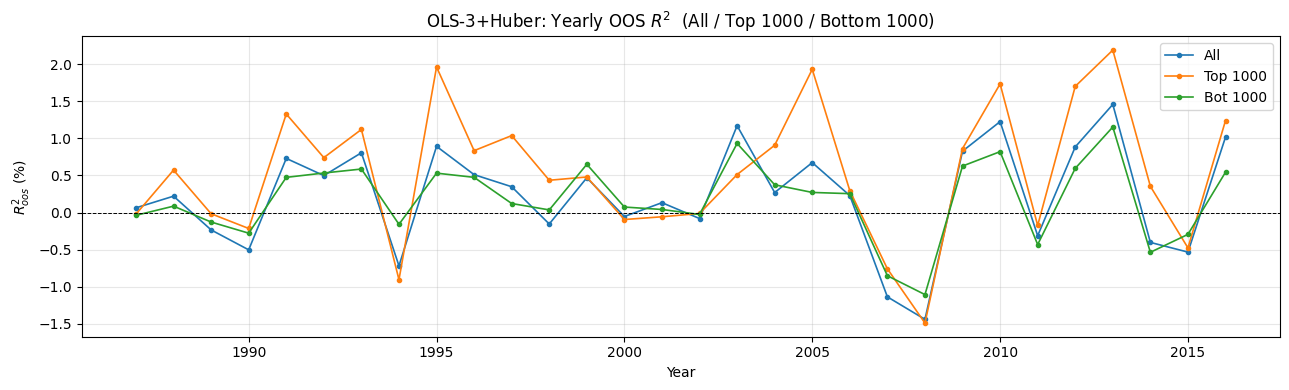

           All  Top 1000  Bot 1000
year                              
1987  0.063502 -0.022127 -0.037679
1988  0.220418  0.571983  0.085998
1989 -0.234197 -0.016401 -0.128105
1990 -0.502758 -0.214772 -0.278121
1991  0.729109  1.327882  0.473967
1992  0.497662  0.739632  0.532423
1993  0.805132  1.119438  0.586128
1994 -0.718600 -0.904742 -0.158714
1995  0.891735  1.961523  0.530705
1996  0.510399  0.833571  0.474128
1997  0.347628  1.036844  0.121520
1998 -0.154497  0.434853  0.035320
1999  0.468582  0.479048  0.649694
2000 -0.053832 -0.094173  0.073854
2001  0.132682 -0.057296  0.041149
2002 -0.080826 -0.012524 -0.026284
2003  1.170184  0.511513  0.930862
2004  0.269347  0.906494  0.373909
2005  0.672774  1.929913  0.270755
2006  0.228329  0.294178  0.254203
2007 -1.136395 -0.758379 -0.851646
2008 -1.439380 -1.489541 -1.105739
2009  0.827184  0.861912  0.626349
2010  1.225221  1.733314  0.820294
2011 -0.312251 -0.174015 -0.431638
2012  0.883769  1.700216  0.595048
2013  1.456507  2.18

In [ ]:
results['year']  = results['DATE'].dt.year
top1000['year']  = top1000['DATE'].dt.year
bot1000['year']  = bot1000['DATE'].dt.year

yearly_r2 = []
for yr in sorted(results['year'].unique()):
    m_all = results['year'] == yr
    m_top = top1000['year'] == yr
    m_bot = bot1000['year'] == yr
    yearly_r2.append({
        'year':       yr,
        'All':        oos_r2(results.loc[m_all,'y_true'], results.loc[m_all,'y_pred']) * 100,
        'Top 1000':   oos_r2(top1000.loc[m_top,'y_true'], top1000.loc[m_top,'y_pred']) * 100,
        'Bot 1000':   oos_r2(bot1000.loc[m_bot,'y_true'], bot1000.loc[m_bot,'y_pred']) * 100,
    })

df_yr = pd.DataFrame(yearly_r2).set_index('year')

fig, ax = plt.subplots(figsize=(13, 4))
df_yr.plot(ax=ax, marker='o', markersize=3, linewidth=1.2)
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlabel('Year'); ax.set_ylabel(r'$R^2_{oos}$ (%)')
ax.set_title('OLS-3+Huber: Yearly OOS $R^2$  (All / Top 1000 / Bottom 1000)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(df_yr.to_string())

## 6. Monthly $R^2_{oos}$ Bar Chart

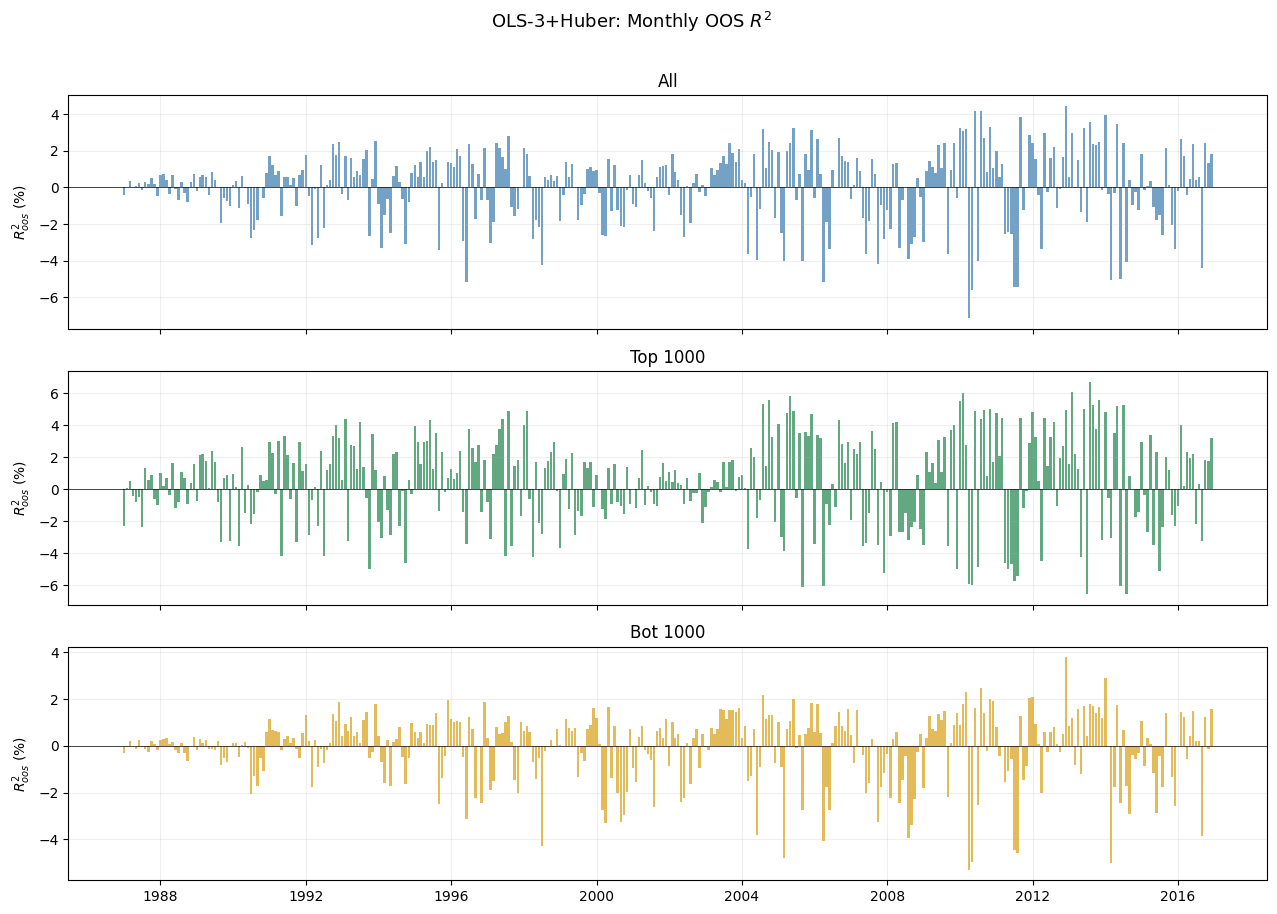

In [ ]:
for df_sub, label in [(results, 'All'), (top1000, 'Top 1000'), (bot1000, 'Bot 1000')]:
    df_sub['ym'] = df_sub['DATE'].dt.to_period('M')

monthly_r2 = []
for ym in sorted(results['ym'].unique()):
    row = {'date': ym.to_timestamp()}
    for df_sub, label in [(results,'All'), (top1000,'Top 1000'), (bot1000,'Bot 1000')]:
        m = df_sub['ym'] == ym
        row[label] = oos_r2(df_sub.loc[m,'y_true'], df_sub.loc[m,'y_pred']) * 100 if m.sum() > 0 else np.nan
    monthly_r2.append(row)

df_mon = pd.DataFrame(monthly_r2).set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ['steelblue', 'seagreen', 'goldenrod']
for ax, col, clr in zip(axes, df_mon.columns, colors):
    ax.bar(df_mon.index, df_mon[col], width=25, color=clr, alpha=0.75)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_ylabel(r'$R^2_{oos}$ (%)')
    ax.set_title(col)
    ax.grid(alpha=0.2)

plt.suptitle('OLS-3+Huber: Monthly OOS $R^2$', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 7. Summary Statistics

In [ ]:
for df_sub, label in [(results,'All'), (top1000,'Top 1000'), (bot1000,'Bot 1000')]:
    n = df_sub.groupby('DATE').size()
    print(f"{label:15s}  total={len(df_sub):,}  per-month: mean={n.mean():.0f}, "
          f"min={n.min()}, max={n.max()}")

All              total=2,476,033  per-month: mean=6878, min=5416, max=8968
Top 1000         total=360,000  per-month: mean=1000, min=1000, max=1000
Bot 1000         total=360,000  per-month: mean=1000, min=1000, max=1000


---
**End of notebook.**

Expected results (Table 1, OLS-3+H column):
- All stocks: **+0.16%**
- Top 1,000:  **+0.31%**
- Bottom 1,000: **+0.17%**